CL=F (WTI 원유) 데이터 수집 중...


[*********************100%***********************]  1 of 1 completed


✅ 'wti_oil_5yr_data.csv' 파일 저장 완료!


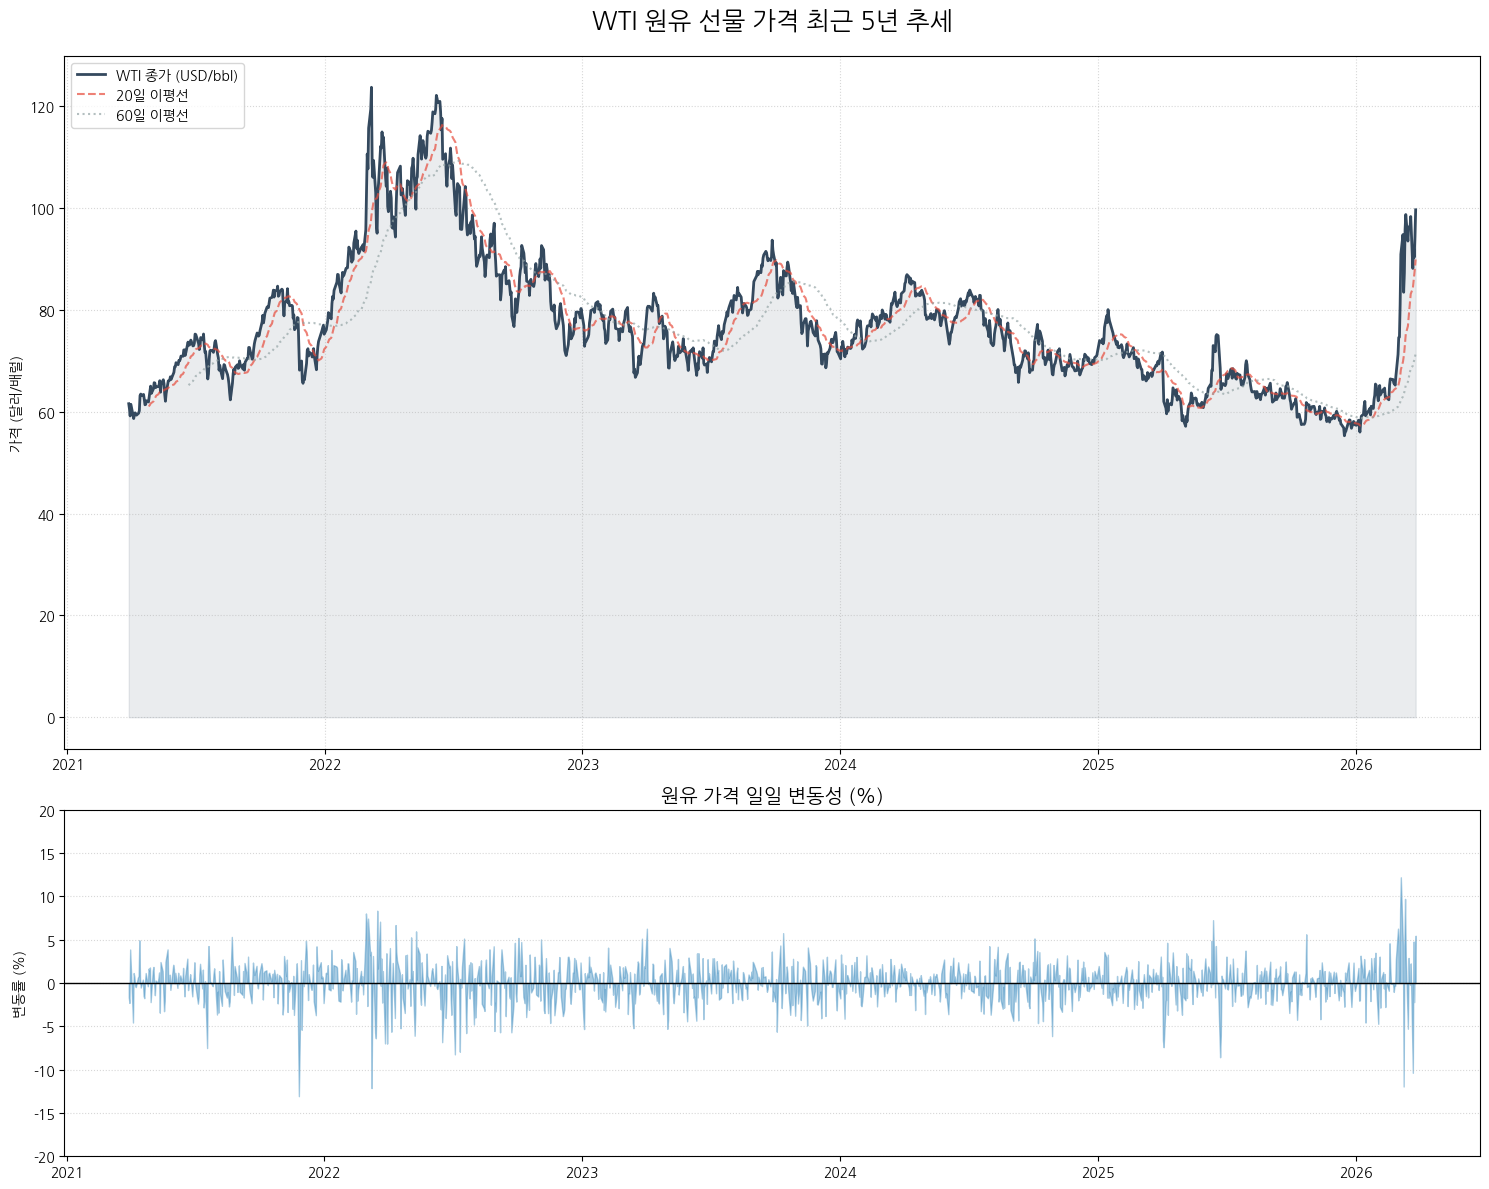


--- CL=F 분석 요약 ---
현재 시세: $99.64
5년 최고점: $123.70
5년 최저점: $55.27
평균 변동성: ±2.38%


In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
from datetime import datetime, timedelta

# 1. 데이터 수집 (WTI 원유 선물: CL=F)
ticker = "CL=F"
end = datetime.now()
start = end - timedelta(days=5*365)

print(f"{ticker} (WTI 원유) 데이터 수집 중...")
# 원유 데이터는 변동이 심해 auto_adjust=True 권장
df = yf.download(ticker, start=start, end=end, auto_adjust=True)

# Multi-index 처리 (최신 yfinance 대응)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 2. 데이터 가공
df['일일수익률'] = df['Close'].pct_change() * 100
df['20일평균'] = df['Close'].rolling(window=20).mean()
df['60일평균'] = df['Close'].rolling(window=60).mean()

# 3. CSV 파일 저장
file_name = "wti_oil_5yr_data.csv"
df.to_csv(file_name)
print(f"✅ '{file_name}' 파일 저장 완료!")

# 4. 시각화 (석유 특화 분석)
fig, ax = plt.subplots(2, 1, figsize=(15, 12), gridspec_kw={'height_ratios': [2, 1]})

# [상단] 가격 추세 및 이동평균선
ax[0].plot(df.index, df['Close'], label='WTI 종가 (USD/bbl)', color='#34495E', linewidth=2)
ax[0].plot(df.index, df['20일평균'], label='20일 이평선', color='#E74C3C', linestyle='--', alpha=0.7)
ax[0].plot(df.index, df['60일평균'], label='60일 이평선', color='#95A5A6', linestyle=':', alpha=0.7)

# 2020년 마이너스 유가 사태 등 특이점 강조를 위한 배경색
ax[0].fill_between(df.index, df['Close'], color='#34495E', alpha=0.1)

ax[0].set_title('WTI 원유 선물 가격 최근 5년 추세', fontsize=18, pad=20)
ax[0].set_ylabel('가격 (달러/배럴)')
ax[0].legend(loc='upper left')
ax[0].grid(True, linestyle=':', alpha=0.5)

# [하단] 일일 변동성 (수익률)
ax[1].fill_between(df.index, df['일일수익률'], color='#2980B9', alpha=0.4, label='수익률 변동폭')
ax[1].axhline(0, color='black', linewidth=1)
ax[1].set_title('원유 가격 일일 변동성 (%)', fontsize=14)
ax[1].set_ylabel('변동률 (%)')
ax[1].set_ylim(-20, 20) # 유가는 변동성이 커서 범위를 넓게 잡음
ax[1].grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# 5. 주요 통계치 출력
print(f"\n--- {ticker} 분석 요약 ---")
print(f"현재 시세: ${df['Close'].iloc[-1]:.2f}")
print(f"5년 최고점: ${df['Close'].max():.2f}")
print(f"5년 최저점: ${df['Close'].min():.2f}")
print(f"평균 변동성: ±{df['일일수익률'].std():.2f}%")